# $\alpha_L$ versus $\Delta E$, up to 28 plaquettes

In [1]:
import os
import sys
from pathlib import Path
import pickle
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
from scipy.optimize import curve_fit
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
jax.config.update('jax_enable_x64', True)

In [2]:
excited_links = {
    4: [
        [5],
        [8],
        [11, 13],
        [14, 16],
        [17, 19, 22],
        [20, 22, 25],
        [23, 25, 28, 31]
    ],
    6: [
        [],
        [12],
        [17],
        [21, 24],
    ],
    8: [
        [10],
        [16],
        [22, 24]
    ]
}

In [3]:
plaquette_energy = 0.5

filename = '/data/iiyama/2dz2/sqd_hstack.h5'

if not os.path.exists(filename):
    with h5py.File('/data/iiyama/2dz2/sqd_hstack.h5', 'w', libver='latest') as out:
        for rows in [4, 6, 8]:
            group = out.create_group(f'row{rows}')
            e0s = group.create_dataset('e0', shape=(len(excited_links[rows])), dtype=np.float64)
            s2s = group.create_dataset('s2', shape=(len(excited_links[rows])), dtype=np.int32)
            s3s = group.create_dataset('s3', shape=(len(excited_links[rows])), dtype=np.int32)
            s4s = group.create_dataset('s4', shape=(len(excited_links[rows])), dtype=np.int32)
            a2s = group.create_dataset('a2', shape=(len(excited_links[rows])), dtype=np.float64)
            a3s = group.create_dataset('a3', shape=(len(excited_links[rows])), dtype=np.float64)
            a4s = group.create_dataset('a4', shape=(len(excited_links[rows])), dtype=np.float64)
            b2s = group.create_dataset('b2', shape=(len(excited_links[rows])), dtype=np.float64)
            b3s = group.create_dataset('b3', shape=(len(excited_links[rows])), dtype=np.float64)
            b4s = group.create_dataset('b4', shape=(len(excited_links[rows])), dtype=np.float64)
            energy_s2s = group.create_dataset('energy_s2', shape=(len(excited_links[rows])), dtype=np.float64)
            energy_s3s = group.create_dataset('energy_s3', shape=(len(excited_links[rows])), dtype=np.float64)
            energy_s4s = group.create_dataset('energy_s4', shape=(len(excited_links[rows])), dtype=np.float64)

            for iconfig, links in enumerate(excited_links[rows]):
                cols = iconfig + 1
                print(rows, cols)
                lattice = TriangularZ2Lattice((rows, cols))
                nplaq = lattice.num_plaquettes

                base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
                base_link_state[::-1][links] = 1
                dual_lattice = lattice.plaquette_dual(base_link_state)
                hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

                hvec = make_hvec(hamiltonian)

                @jax.jit
                def compute():
                    xmat = jax.nn.one_hot(0, 2 ** nplaq, dtype=np.complex128)[:, None]
                    # pylint: disable-next=unbalanced-tuple-unpacking
                    vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)
                    return -vals[0], jnp.square(jnp.abs(vecs[:, 0]))

                e0, probs_ground = compute()
                print('computed')
                e0s[iconfig] = e0

                sort_idx_ground = np.argsort(probs_ground)[::-1]
                sorted_probs_ground = np.sort(probs_ground)[::-1]
                cum_probs_ground = np.cumsum(sorted_probs_ground)
                s2 = np.searchsorted(cum_probs_ground, 0.99)
                s3 = np.searchsorted(cum_probs_ground, 0.999)
                s4 = np.searchsorted(cum_probs_ground, 0.9999)
                s2s[iconfig] = s2
                s3s[iconfig] = s3
                s4s[iconfig] = s4
                a2s[iconfig] = cum_probs_ground[s2]
                a3s[iconfig] = cum_probs_ground[s3]
                a4s[iconfig] = cum_probs_ground[s4]
                b2s[iconfig] = sorted_probs_ground[s2]
                b3s[iconfig] = sorted_probs_ground[s3]
                b4s[iconfig] = sorted_probs_ground[s4]

                if s2 <= 5:
                    hmat = hamiltonian.to_matrix().real[sort_idx_ground[:s2]][:, sort_idx_ground[:s2]]
                    energy_s2 = np.linalg.eigvalsh(hmat)[0]
                else:
                    states_s2 = ((sort_idx_ground[:s2, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
                    energy_s2 = sqd(hamiltonian, states_s2)[0]
                states_s3 = ((sort_idx_ground[:s3, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
                energy_s3 = sqd(hamiltonian, states_s3)[0]
                states_s4 = ((sort_idx_ground[:s4, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
                energy_s4 = sqd(hamiltonian, states_s4)[0]
                energy_s2s[iconfig] = energy_s2
                energy_s3s[iconfig] = energy_s3
                energy_s4s[iconfig] = energy_s4


4 1


INFO:2025-12-24 14:10:08,759:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


computed


INFO:skqd_z2lgt.sqd:0.349861 seconds to sort 7 bitstrings
INFO:skqd_z2lgt.sqd:3.168944 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.313916 seconds to sort 9 bitstrings
INFO:skqd_z2lgt.sqd:3.374633 seconds to diagonalize


4 2
computed


...

INFO:skqd_z2lgt.sqd:0.002557 seconds to sort 8 bitstrings
INFO:skqd_z2lgt.sqd:0.146905 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.221038 seconds to sort 21 bitstrings
INFO:skqd_z2lgt.sqd:3.537539 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.531830 seconds to sort 39 bitstrings
INFO:skqd_z2lgt.sqd:4.189627 seconds to diagonalize


8 2
computed


INFO:skqd_z2lgt.sqd:0.373786 seconds to sort 30 bitstrings
INFO:skqd_z2lgt.sqd:4.433665 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.891505 seconds to sort 134 bitstrings
INFO:skqd_z2lgt.sqd:4.668479 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.933350 seconds to sort 473 bitstrings
INFO:skqd_z2lgt.sqd:5.015644 seconds to diagonalize


8 3
computed


INFO:skqd_z2lgt.sqd:0.857138 seconds to sort 147 bitstrings
INFO:skqd_z2lgt.sqd:5.063034 seconds to diagonalize
INFO:skqd_z2lgt.sqd:1.255752 seconds to sort 1083 bitstrings
INFO:skqd_z2lgt.sqd:6.006679 seconds to diagonalize
INFO:skqd_z2lgt.sqd:2.244503 seconds to sort 4829 bitstrings
INFO:skqd_z2lgt.sqd:7.500769 seconds to diagonalize


In [4]:
with h5py.File(filename, 'r', libver='latest') as source:
    e0s = {rows: source[f'row{rows}/e0'][()] for rows in [4, 6, 8]}
    s2s = {rows: source[f'row{rows}/s2'][()] for rows in [4, 6, 8]}
    s3s = {rows: source[f'row{rows}/s3'][()] for rows in [4, 6, 8]}
    s4s = {rows: source[f'row{rows}/s4'][()] for rows in [4, 6, 8]}
    a2s = {rows: source[f'row{rows}/a2'][()] for rows in [4, 6, 8]}
    a3s = {rows: source[f'row{rows}/a3'][()] for rows in [4, 6, 8]}
    a4s = {rows: source[f'row{rows}/a4'][()] for rows in [4, 6, 8]}
    energy_s2s = {rows: source[f'row{rows}/energy_s2'][()] for rows in [4, 6, 8]}
    energy_s3s = {rows: source[f'row{rows}/energy_s3'][()] for rows in [4, 6, 8]}
    energy_s4s = {rows: source[f'row{rows}/energy_s4'][()] for rows in [4, 6, 8]}

Text(0.5, 0, '$-\\frac{1}{2}ln(1 - \\sqrt{\\alpha_L})$')

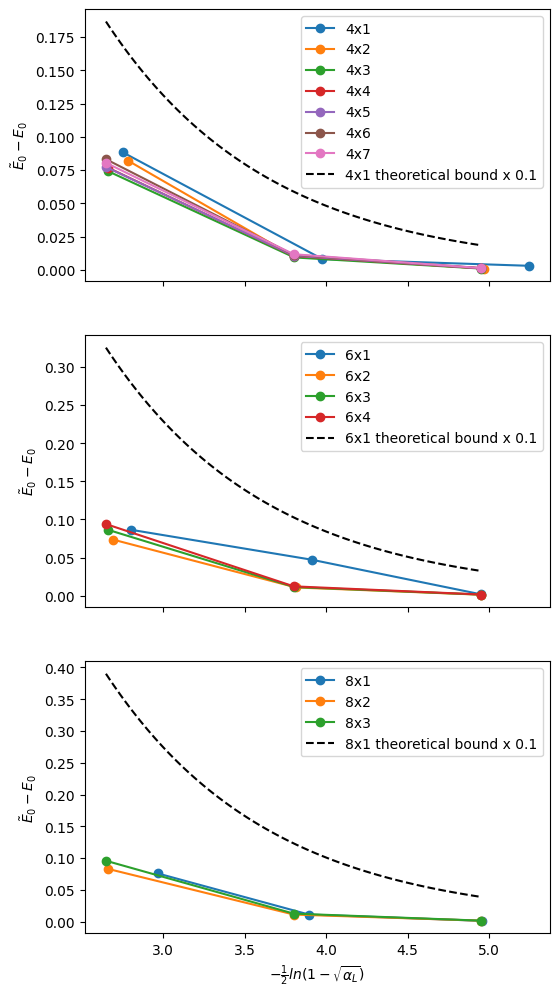

In [5]:
fig, axs = plt.subplots(3, figsize=(6., 12.), sharex=True)
for rows, ax in zip([4, 6, 8], axs):
    for icol in range(e0s[rows].shape[0]):
        alpha_l = np.array([a2s[rows][icol], a3s[rows][icol], a4s[rows][icol]])
        alt_eps = np.sqrt(1. - np.sqrt(alpha_l))
        energy_error = np.array([energy_s2s[rows][icol], energy_s3s[rows][icol], energy_s4s[rows][icol]]) - e0s[rows][icol]
        ax.plot(-np.log(alt_eps), energy_error, marker='o', label=f'{rows}x{icol + 1}')

    xbounds = -np.log(np.sqrt(1. - np.sqrt([0.99, 0.9999])))
    x = np.linspace(xbounds[0], xbounds[1], 100)
    ax.plot(x, np.sqrt(8.) * np.abs(e0s[rows][0]) * np.exp(-x) * 0.1, ls='--', color='k', label=f'{rows}x1 theoretical bound x 0.1')
    ax.set_ylabel(r'$\tilde{E}_0 - E_0$')
    ax.legend()
ax.set_xlabel(r'$-\frac{1}{2}ln(1 - \sqrt{\alpha_L})$')

In [19]:
np.exp(-x)

array([0.07079946, 0.06917091, 0.06757981, 0.06602532, 0.06450659,
       0.06302279, 0.06157312, 0.0601568 , 0.05877305, 0.05742114,
       0.05610032, 0.05480988, 0.05354913, 0.05231737, 0.05111395,
       0.04993822, 0.04878952, 0.04766725, 0.04657079, 0.04549956,
       0.04445296, 0.04343044, 0.04243144, 0.04145542, 0.04050185,
       0.03957022, 0.03866001, 0.03777074, 0.03690193, 0.0360531 ,
       0.03522379, 0.03441357, 0.03362197, 0.03284859, 0.032093  ,
       0.03135479, 0.03063355, 0.02992891, 0.02924048, 0.02856788,
       0.02791075, 0.02726874, 0.0266415 , 0.02602868, 0.02542996,
       0.02484501, 0.02427352, 0.02371517, 0.02316967, 0.02263672,
       0.02211602, 0.0216073 , 0.02111028, 0.0206247 , 0.02015028,
       0.01968678, 0.01923394, 0.01879151, 0.01835926, 0.01793696,
       0.01752437, 0.01712127, 0.01672744, 0.01634267, 0.01596675,
       0.01559948, 0.01524065, 0.01489008, 0.01454758, 0.01421295,
       0.01388602, 0.01356661, 0.01325455, 0.01294966, 0.01265

In [16]:
rows = 8
icol = 2
alpha_l = np.array([a2s[rows][icol], a3s[rows][icol], a4s[rows][icol]])
alt_eps = np.sqrt(1. - np.sqrt(alpha_l))

In [17]:
alt_eps

array([0.07076219, 0.02235897, 0.00707069])

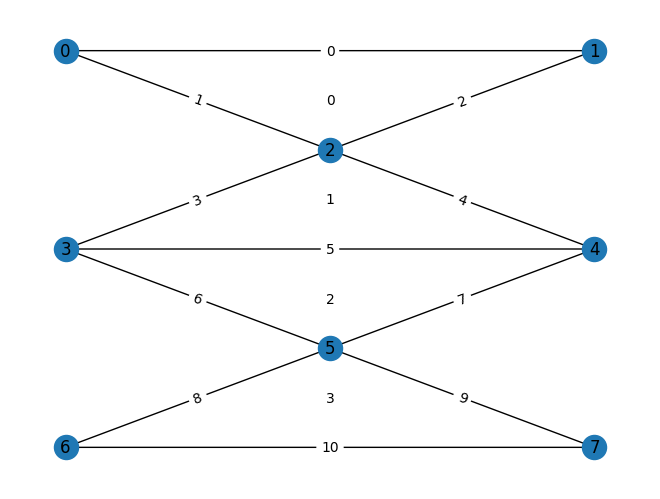

In [21]:
TriangularZ2Lattice(configs[4][0]).draw_graph();

In [22]:
e0s[4][0]

np.float64(-9.313209465803531)